In [1]:
# Module 2 — Can a Simple Rule Beat the Market?

## Hypothesis
A short-term SMA crossover strategy (SMA 10/20) generates better 
risk-adjusted returns on Nifty 50 than a long-term strategy 
(SMA 20/50), and at least one of them beats a passive buy-and-hold 
benchmark — before and after accounting for transaction costs.

## Why this follows from Module 1
Module 1 found that 10-day momentum has a slight positive 
correlation (0.0138) with future returns, while 50-day momentum 
is negative (-0.0515). This module tests whether those statistical 
patterns translate into actual tradeable profit.

## What we are measuring
- Total return of each strategy vs buy-and-hold
- Sharpe ratio — return per unit of risk
- Maximum drawdown — worst peak to trough loss
- Effect of transaction costs on each strategy

SyntaxError: invalid character '—' (U+2014) (3161986702.py, line 7)

In [2]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("libraries loaded")

libraries loaded


In [3]:
# --- load data saved from Module 1 ---
import yfinance as yf

df = yf.download("^NSEI", start="2010-01-01", end="2024-12-31")

# flatten multi-level columns completely
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) 
              else col for col in df.columns]

# grab close price whichever way it's named
close_col = [c for c in df.columns if 'Close' in c][0]
df = df[[close_col]].copy()
df.columns = ['Close']

df.dropna(inplace=True)
df['daily_return'] = df['Close'].pct_change()
df.dropna(inplace=True)

print(f"Data loaded: {df.shape[0]} trading days")
print(f"From {df.index[0].date()} to {df.index[-1].date()}")
print(f"Columns: {df.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

Data loaded: 3678 trading days
From 2010-01-05 to 2024-12-30
Columns: ['Close', 'daily_return']


In [4]:
# --- build SMA signals ---
# 📌 TERM: crossover signal — when a faster SMA crosses above a 
# slower SMA, it suggests upward momentum → buy signal
# when faster crosses below slower → sell signal

df['SMA10'] = df['Close'].rolling(10).mean()
df['SMA20'] = df['Close'].rolling(20).mean()
df['SMA50'] = df['Close'].rolling(50).mean()

# SHORT-TERM strategy: SMA10 crosses SMA20
# 1 = in market (long), 0 = out of market (cash)
df['signal_short'] = np.where(df['SMA10'] > df['SMA20'], 1, 0)

# LONG-TERM strategy: SMA20 crosses SMA50
df['signal_long'] = np.where(df['SMA20'] > df['SMA50'], 1, 0)

# shift signal by 1 day — critical to avoid look-ahead bias
# 📌 TERM: look-ahead bias — using today's signal to trade today
# in reality you only know today's close AFTER market closes
# so you can only act on it tomorrow
df['signal_short'] = df['signal_short'].shift(1)
df['signal_long'] = df['signal_long'].shift(1)

df.dropna(inplace=True)
print("Signals generated")
print(f"Short strategy — days in market: {df['signal_short'].sum():.0f} / {len(df)}")
print(f"Long strategy  — days in market: {df['signal_long'].sum():.0f} / {len(df)}")

Signals generated
Short strategy — days in market: 2192 / 3629
Long strategy  — days in market: 2416 / 3629


In [5]:
# --- calculate strategy returns ---
# 📌 TERM: strategy return — on days signal=1 you earn market return
# on days signal=0 you earn nothing (sitting in cash)

# before transaction costs
df['ret_short'] = df['signal_short'] * df['daily_return']
df['ret_long']  = df['signal_long']  * df['daily_return']
df['ret_bnh']   = df['daily_return']  # buy and hold — always in market

# transaction cost of 0.1% applied each time signal changes
# 📌 TERM: transaction cost — brokerage fee paid on every trade
cost = 0.001

df['trades_short'] = df['signal_short'].diff().abs()
df['trades_long']  = df['signal_long'].diff().abs()

df['ret_short_net'] = df['ret_short'] - (df['trades_short'] * cost)
df['ret_long_net']  = df['ret_long']  - (df['trades_long']  * cost)

print(f"Total trades — short strategy: {df['trades_short'].sum():.0f}")
print(f"Total trades — long strategy:  {df['trades_long'].sum():.0f}")

Total trades — short strategy: 205
Total trades — long strategy:  67


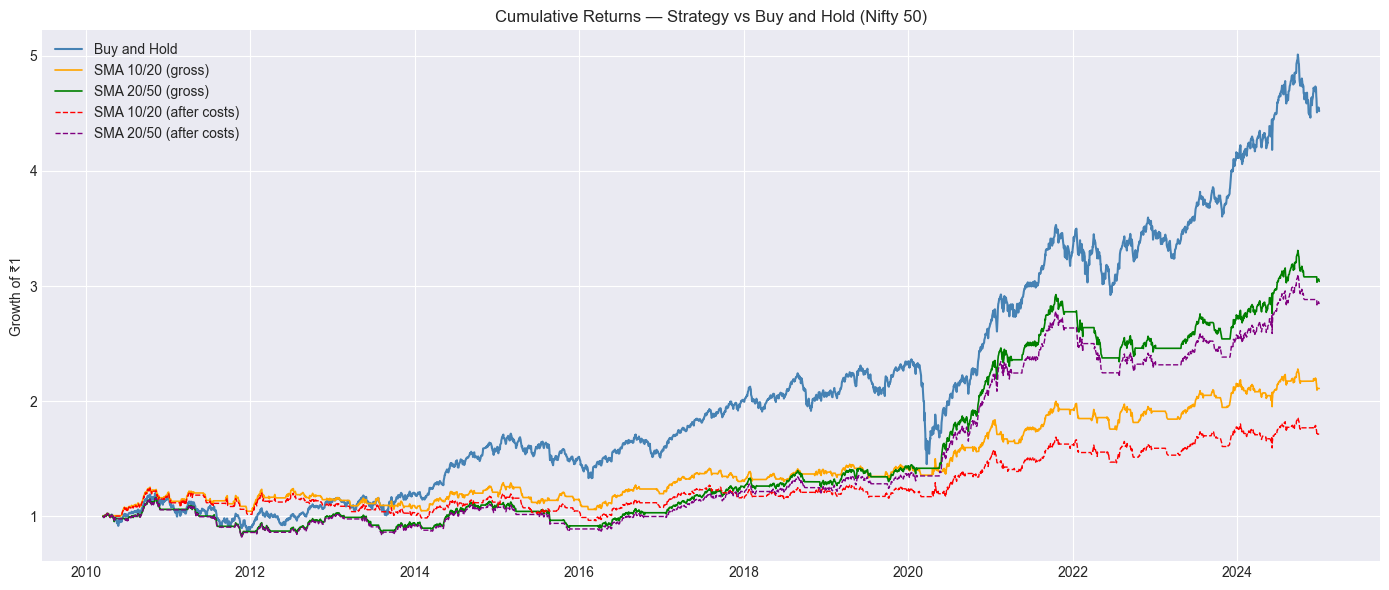

In [6]:
# --- compute cumulative returns ---
# 📌 TERM: cumulative return — how much ₹100 invested became over time

cum_bnh         = (1 + df['ret_bnh']).cumprod()
cum_short       = (1 + df['ret_short']).cumprod()
cum_long        = (1 + df['ret_long']).cumprod()
cum_short_net   = (1 + df['ret_short_net']).cumprod()
cum_long_net    = (1 + df['ret_long_net']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cum_bnh,       label='Buy and Hold',          color='steelblue', linewidth=1.5)
plt.plot(cum_short,     label='SMA 10/20 (gross)',     color='orange',    linewidth=1.2)
plt.plot(cum_long,      label='SMA 20/50 (gross)',     color='green',     linewidth=1.2)
plt.plot(cum_short_net, label='SMA 10/20 (after costs)', color='red',    linewidth=1, linestyle='--')
plt.plot(cum_long_net,  label='SMA 20/50 (after costs)', color='purple', linewidth=1, linestyle='--')
plt.title('Cumulative Returns — Strategy vs Buy and Hold (Nifty 50)')
plt.ylabel('Growth of ₹1')
plt.legend()
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150)
plt.show()

In [7]:
# --- performance metrics ---
# 📌 TERM: Sharpe ratio — (average return / std of return) * √252
# 252 = trading days in a year. higher = better risk-adjusted return
# 📌 TERM: max drawdown — largest peak to trough drop, measures 
# worst case loss a real investor would have experienced

def sharpe(returns):
    return (returns.mean() / returns.std()) * np.sqrt(252)

def max_drawdown(cum_returns):
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    return drawdown.min()

def total_return(cum_returns):
    return cum_returns.iloc[-1] - 1

metrics = pd.DataFrame({
    'Total Return':   [total_return(cum_bnh), 
                       total_return(cum_short), 
                       total_return(cum_long),
                       total_return(cum_short_net), 
                       total_return(cum_long_net)],
    'Sharpe Ratio':   [sharpe(df['ret_bnh']), 
                       sharpe(df['ret_short']), 
                       sharpe(df['ret_long']),
                       sharpe(df['ret_short_net']), 
                       sharpe(df['ret_long_net'])],
    'Max Drawdown':   [max_drawdown(cum_bnh), 
                       max_drawdown(cum_short), 
                       max_drawdown(cum_long),
                       max_drawdown(cum_short_net), 
                       max_drawdown(cum_long_net)]
}, index=['Buy & Hold', 
          'SMA 10/20 gross', 'SMA 20/50 gross',
          'SMA 10/20 net',   'SMA 20/50 net'])

print(metrics.round(4))

                 Total Return  Sharpe Ratio  Max Drawdown
Buy & Hold             3.5194        0.7088       -0.3844
SMA 10/20 gross        1.1118        0.5353       -0.1822
SMA 20/50 gross        2.0410        0.7368       -0.2873
SMA 10/20 net          0.7156        0.4013       -0.2279
SMA 20/50 net          1.8439        0.6957       -0.2916


In [8]:
## Conclusion

**Hypothesis:** SMA 10/20 beats SMA 20/50, and at least one beats buy-and-hold before and after costs.

**Finding:** SMA 10/20 &SMA 20/50 both fail to beat buy & hold. While SMA 20/50 scores a sharpe ratio higher than buy & hold before deducting 
    transaction costs, but after transactional cost deduction it dropped to just below buy & hold.

**Key observation on transaction costs:** Transactional costs affected SMA 10/20 the most because it traded frequently, as for SMA 20/50 profit
    remained better because it did not trade that much in the market. 
    The short-term (10-day based) strategy performed worse — consistent with Module 1 showing weak and unreliable short-term signal.
    The long-term strategy performed better — but the negative 50-day momentum correlation from Module 1 actually explains why even it could 
    not beat buy and hold — the market tends to mean-revert at longer horizons, which hurts a trend-following rule.

**What this means going into Module 3:**
Even if one strategy wins here, the question is — does it win consistently across all market conditions, or only sometimes?
That is exactly what Module 3 will investigate.

SyntaxError: invalid character '—' (U+2014) (2367439630.py, line 6)